DATASET DESCRIPTION
Dataset shape: 11000 rows, 19 columns
Column names: ['Age', 'Gender', 'Occupation', 'Sleep Hours', 'Physical Activity (hrs/week)', 'Caffeine Intake (mg/day)', 'Alcohol Consumption (drinks/week)', 'Smoking', 'Family History of Anxiety', 'Stress Level (1-10)', 'Heart Rate (bpm)', 'Breathing Rate (breaths/min)', 'Sweating Level (1-5)', 'Dizziness', 'Medication', 'Therapy Sessions (per month)', 'Recent Major Life Event', 'Diet Quality (1-10)', 'Anxiety Level (1-10)']
Data types:
Age                                    int64
Gender                                object
Occupation                            object
Sleep Hours                          float64
Physical Activity (hrs/week)         float64
Caffeine Intake (mg/day)               int64
Alcohol Consumption (drinks/week)      int64
Smoking                               object
Family History of Anxiety             object
Stress Level (1-10)                    int64
Heart Rate (bpm)                       int64
Breat

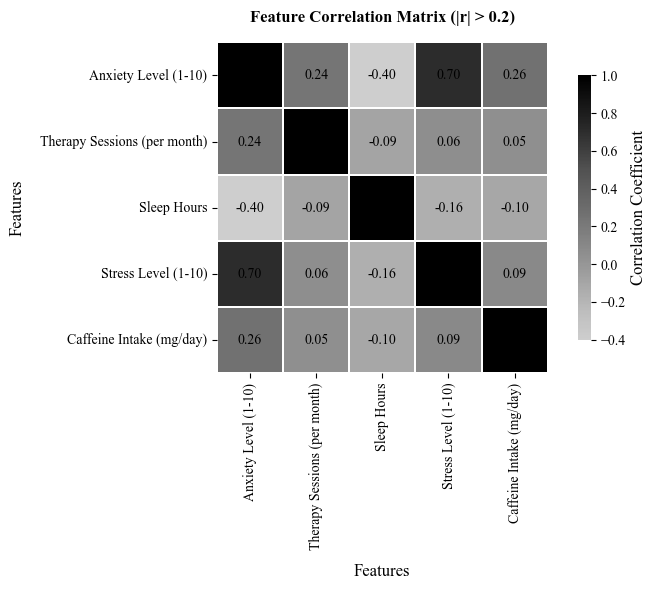

/tmp/ipykernel_3126/2562788784.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.countplot(x=data['Diagnosed'], palette=['#a0a0a0', '#404040'],


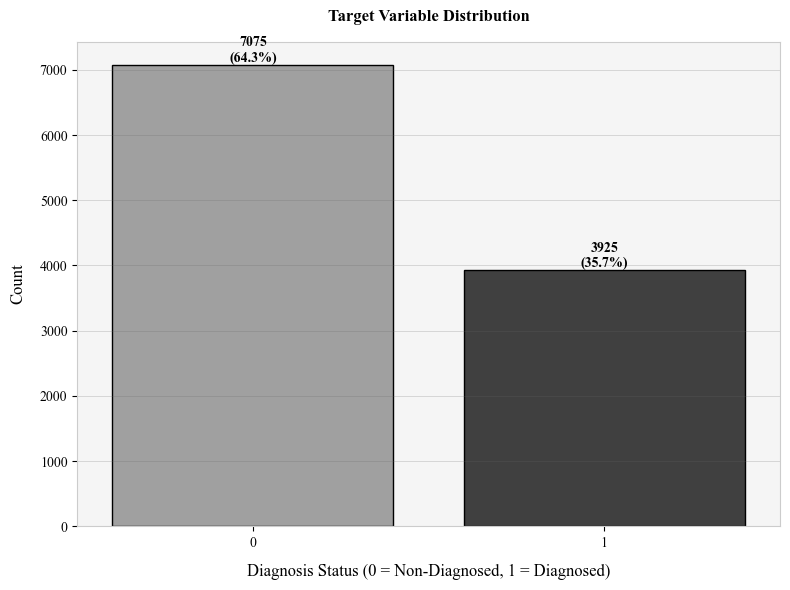

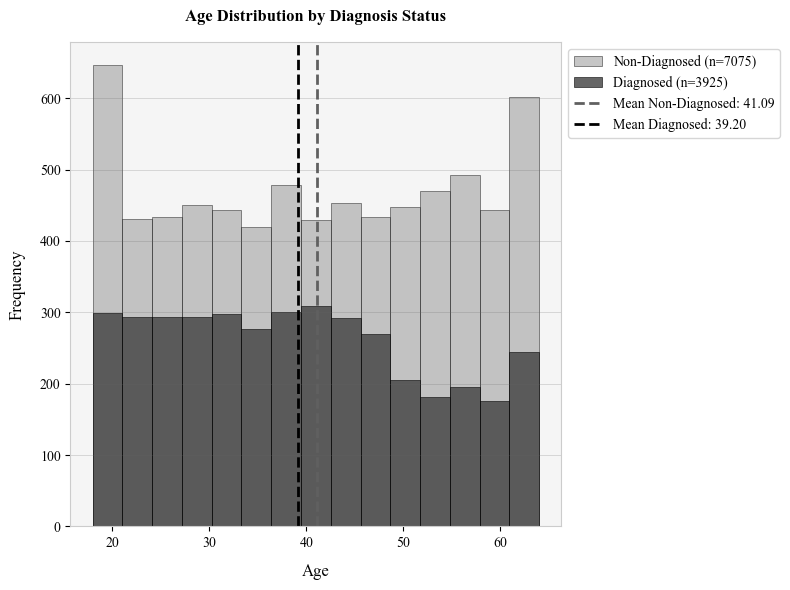

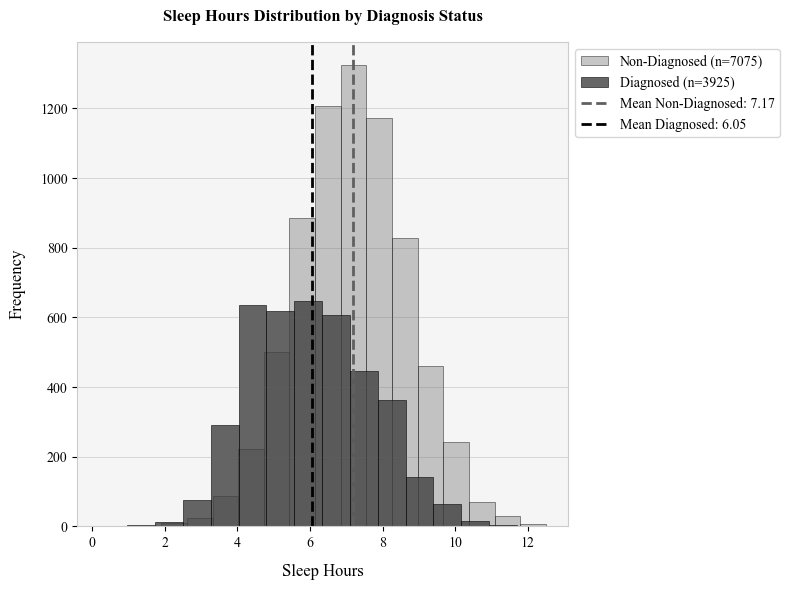

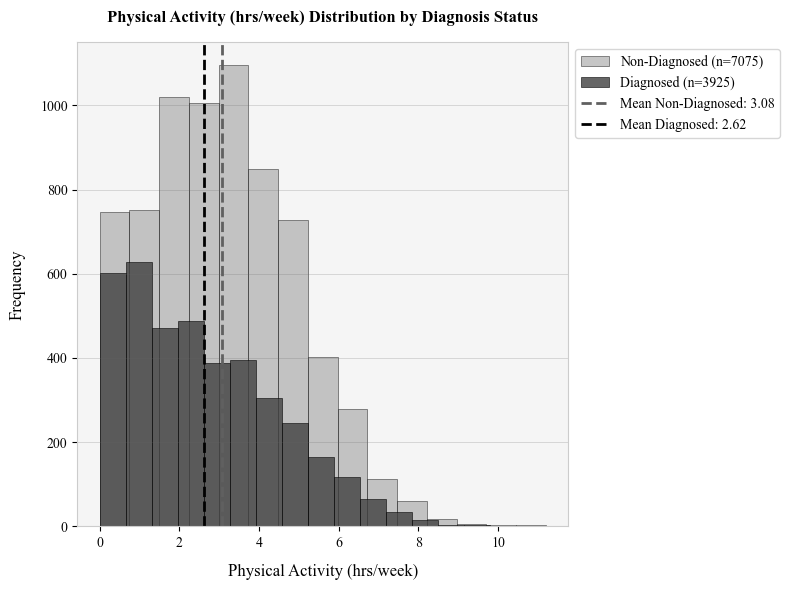

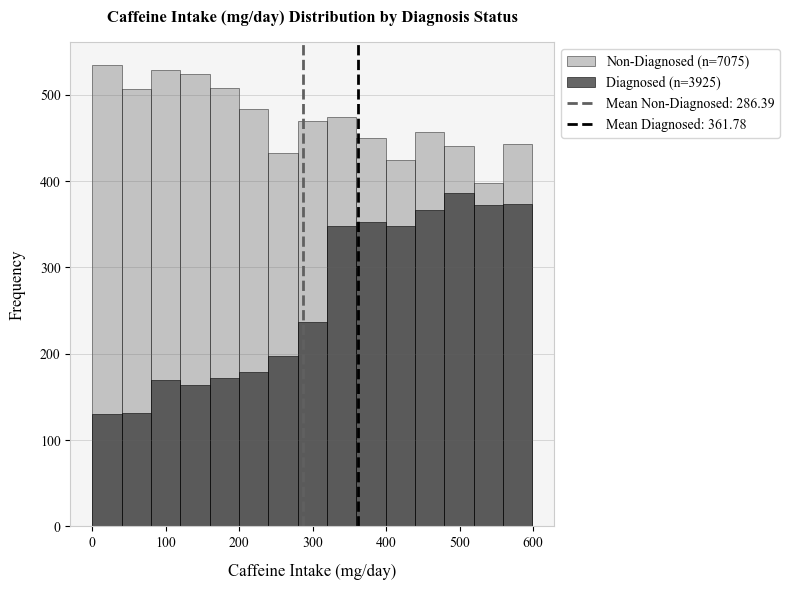

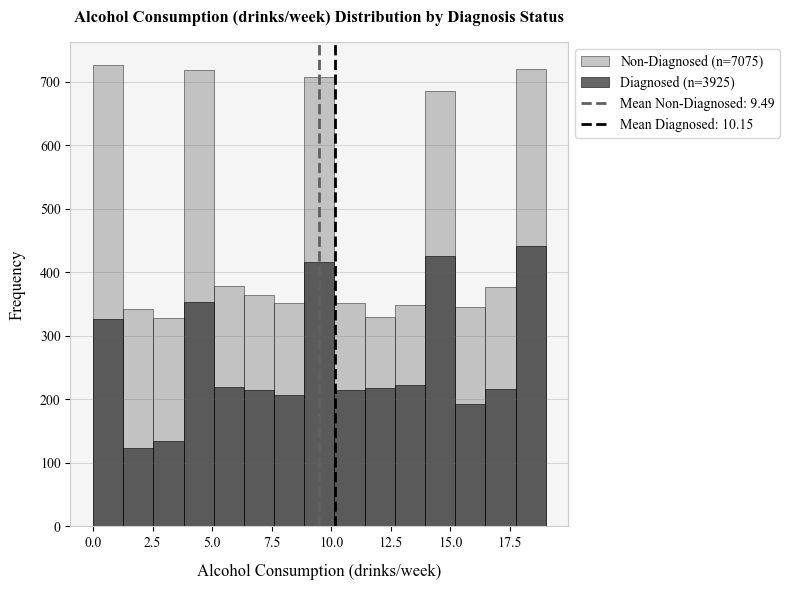

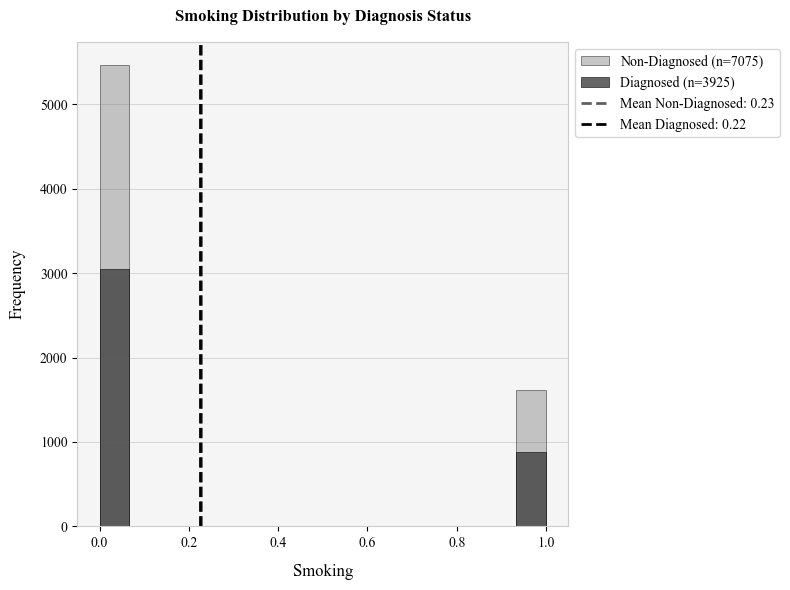

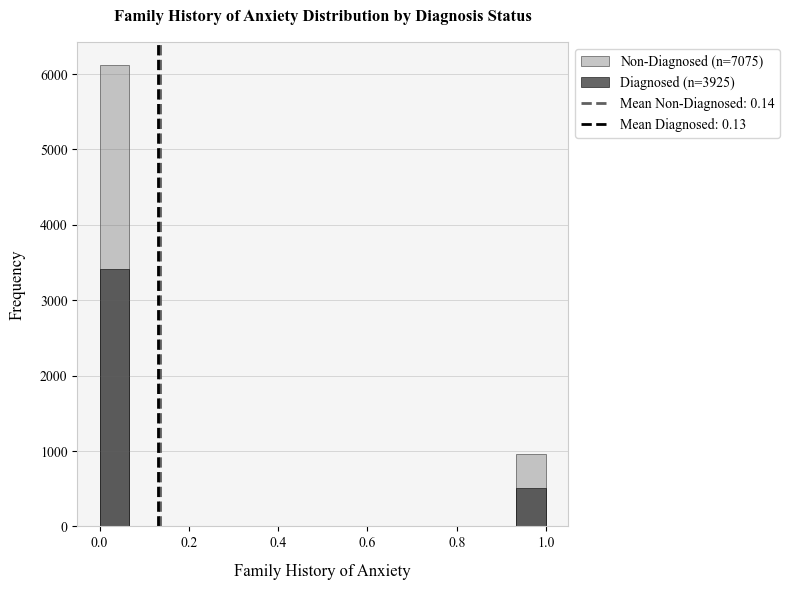

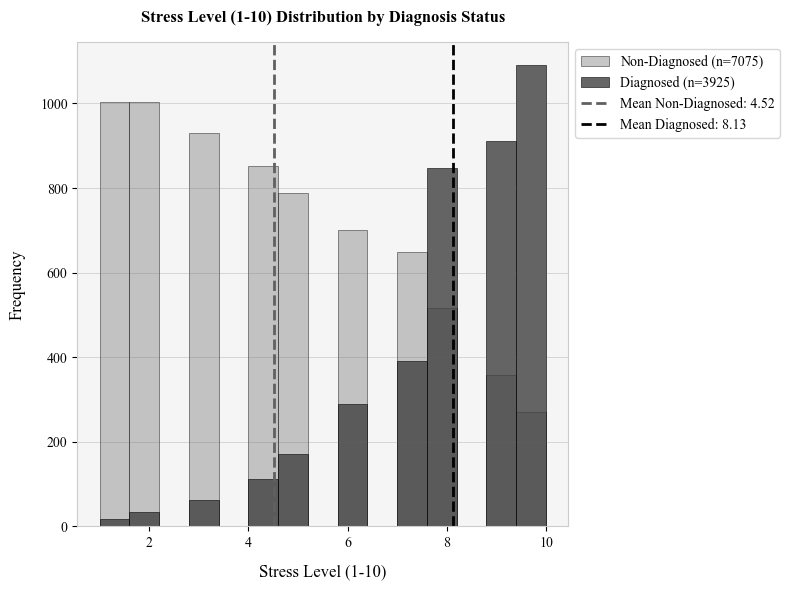

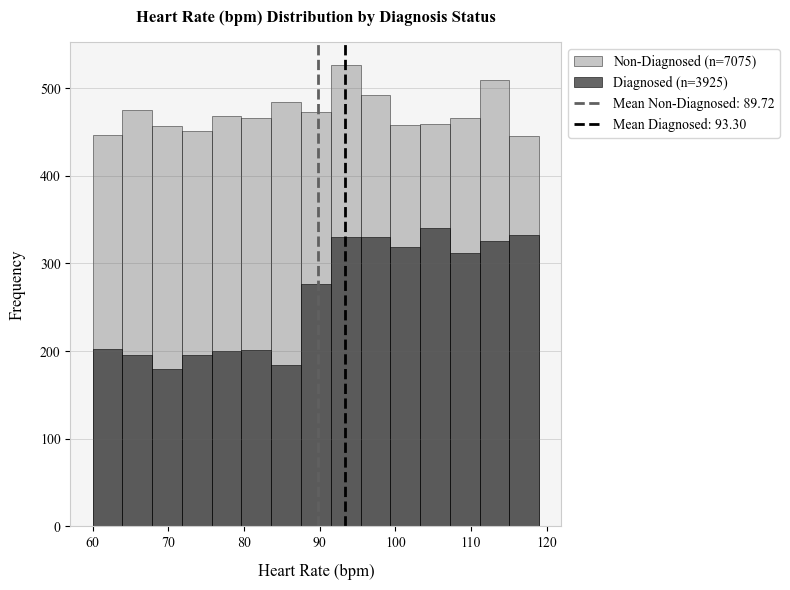

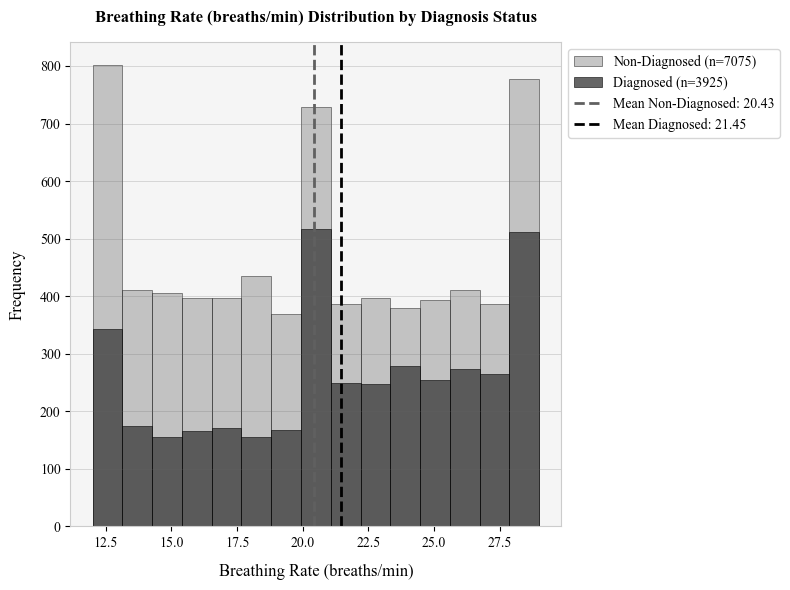

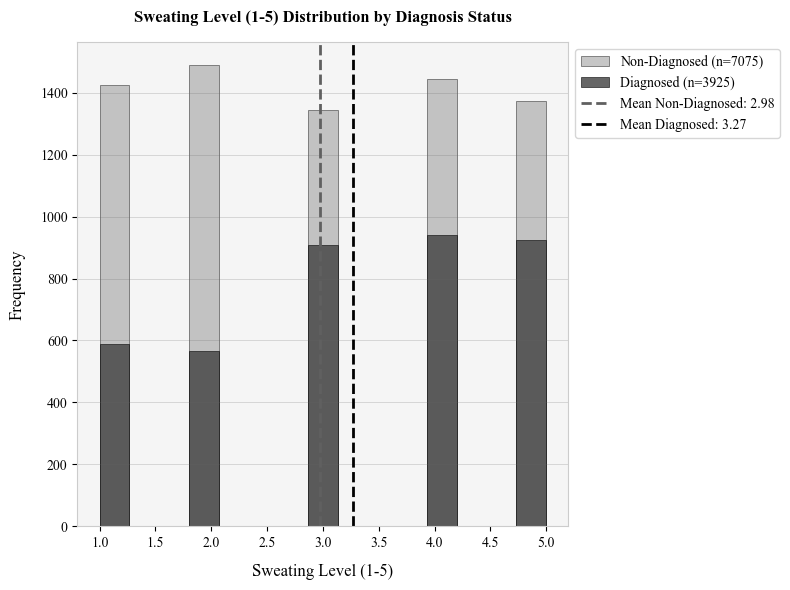

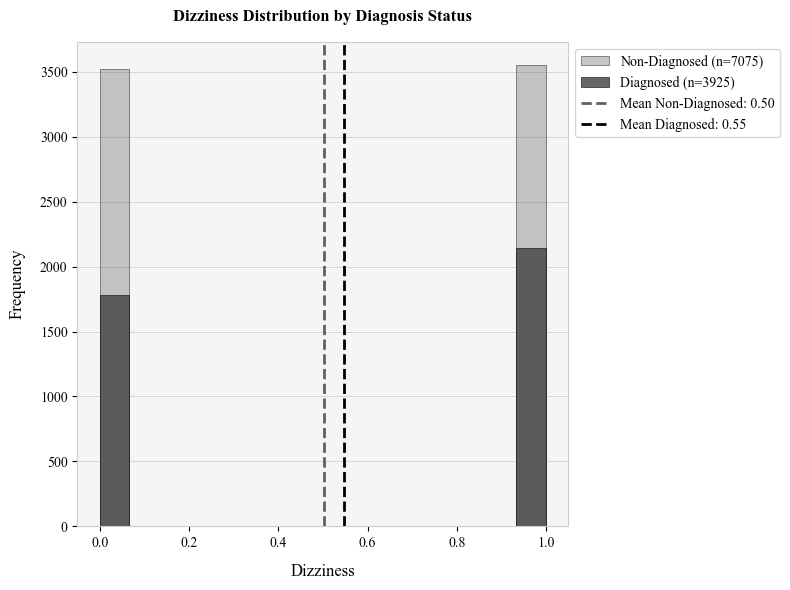

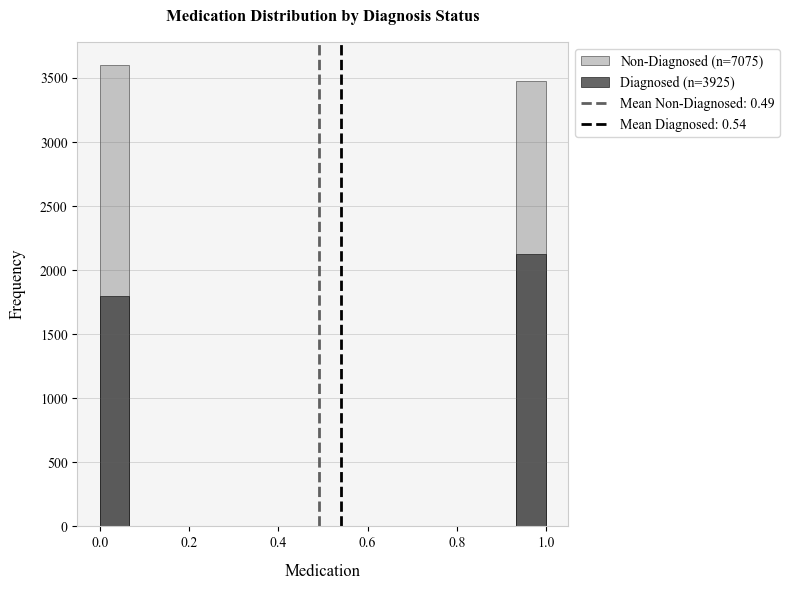

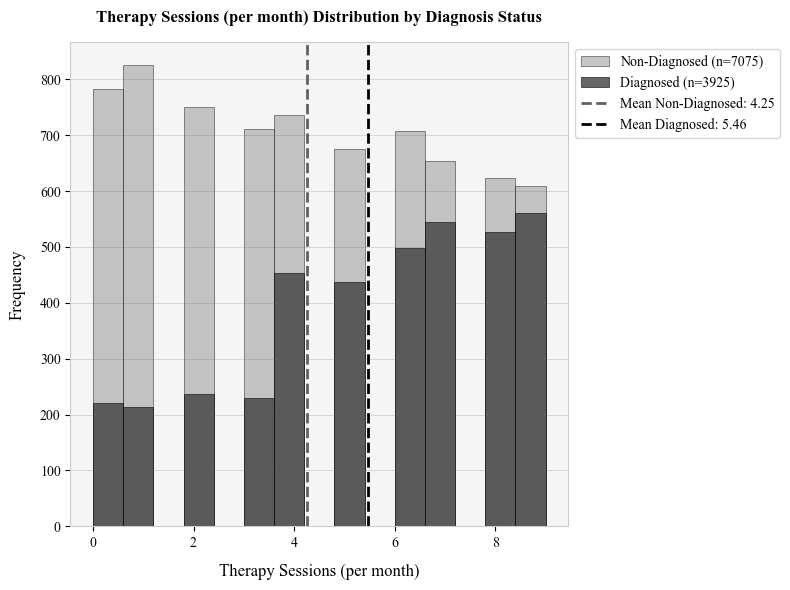

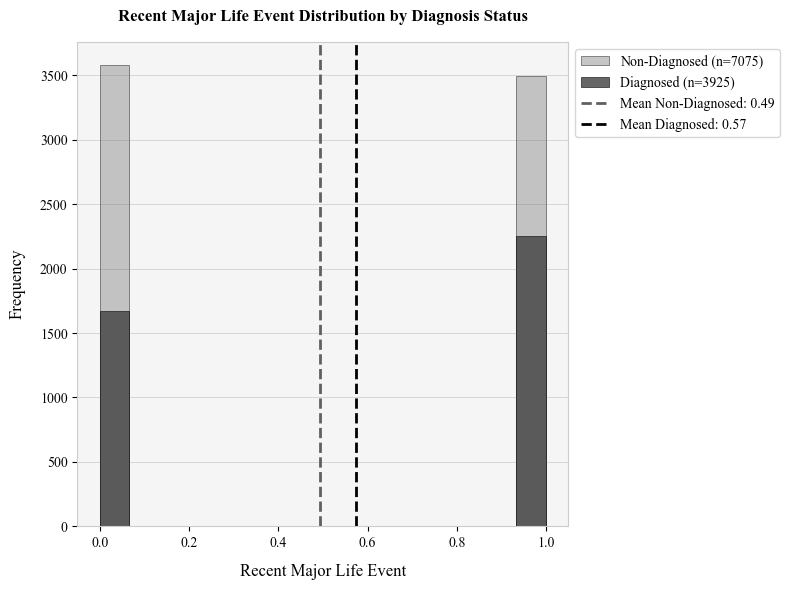

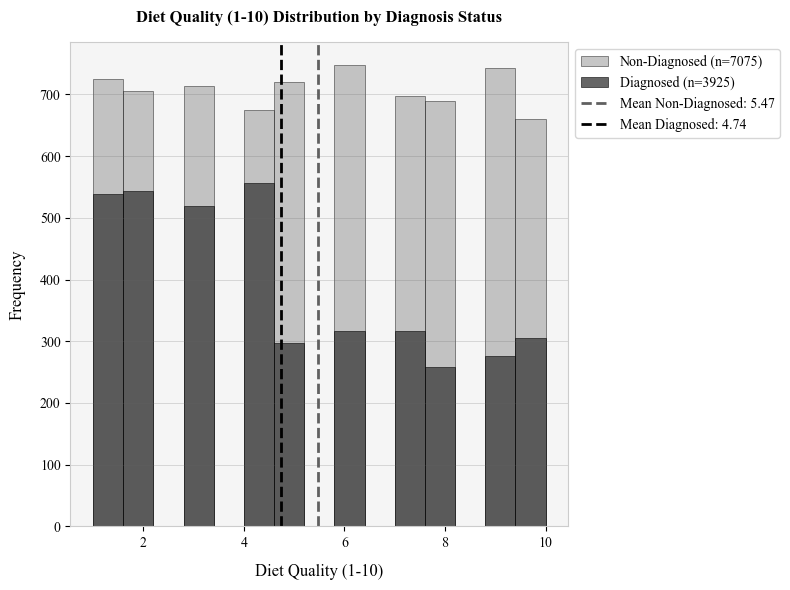

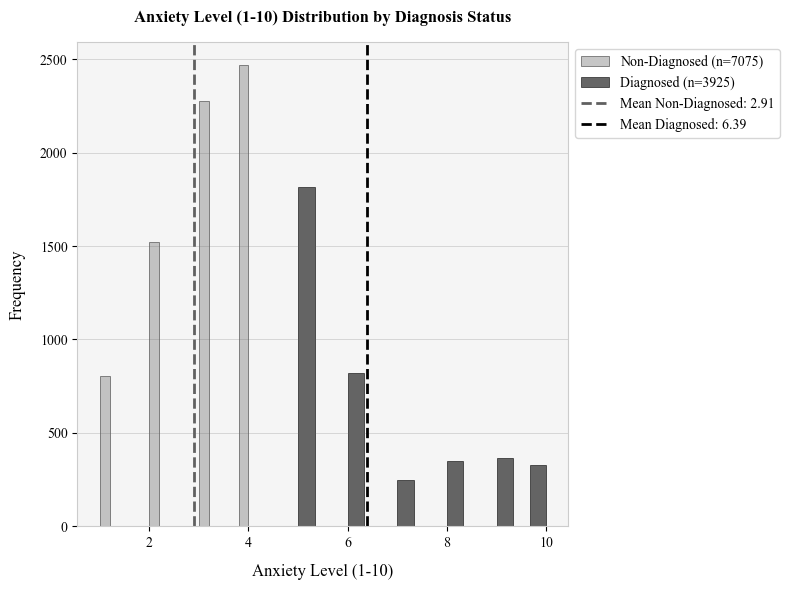

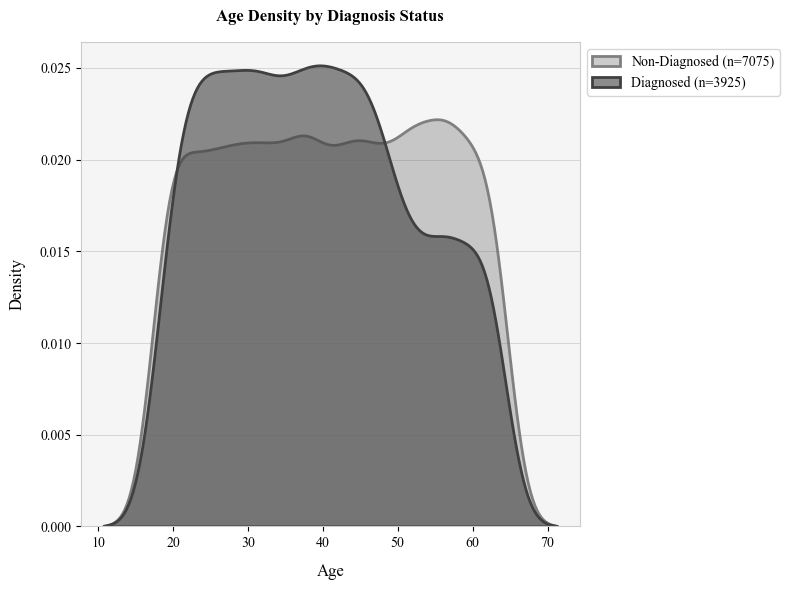

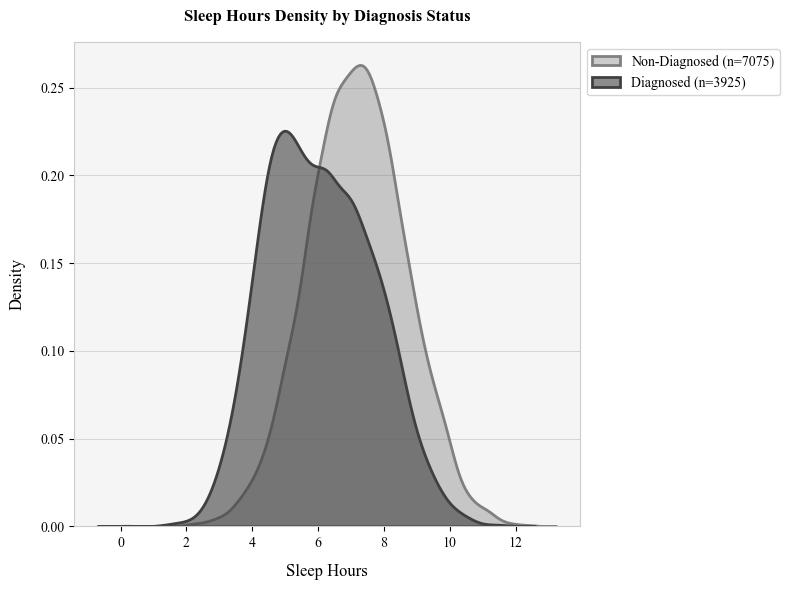

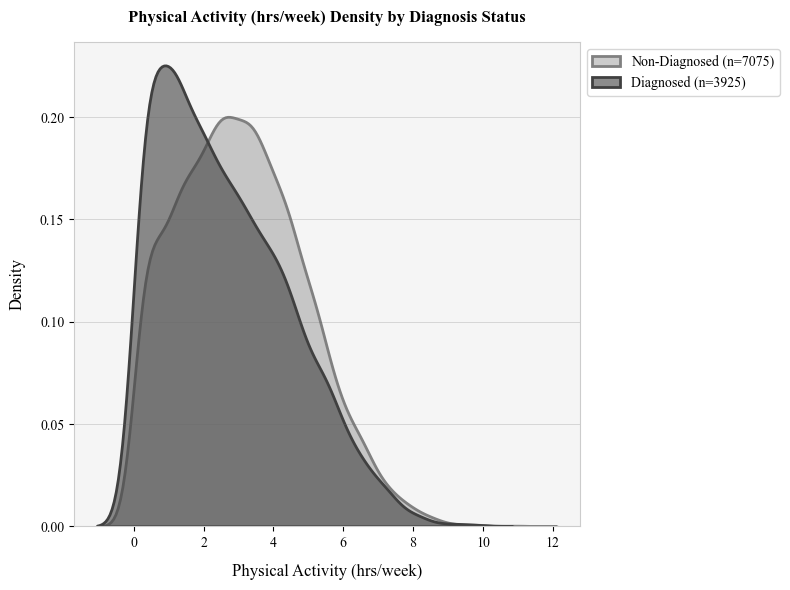

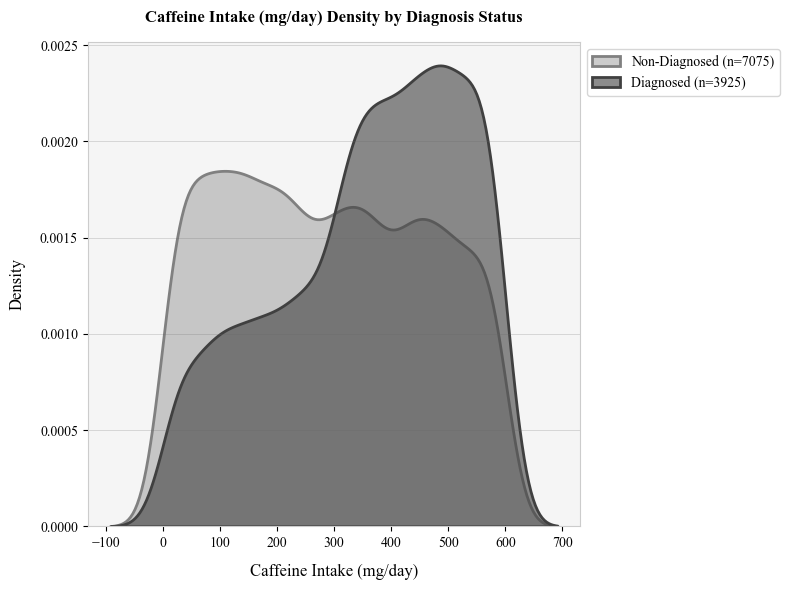

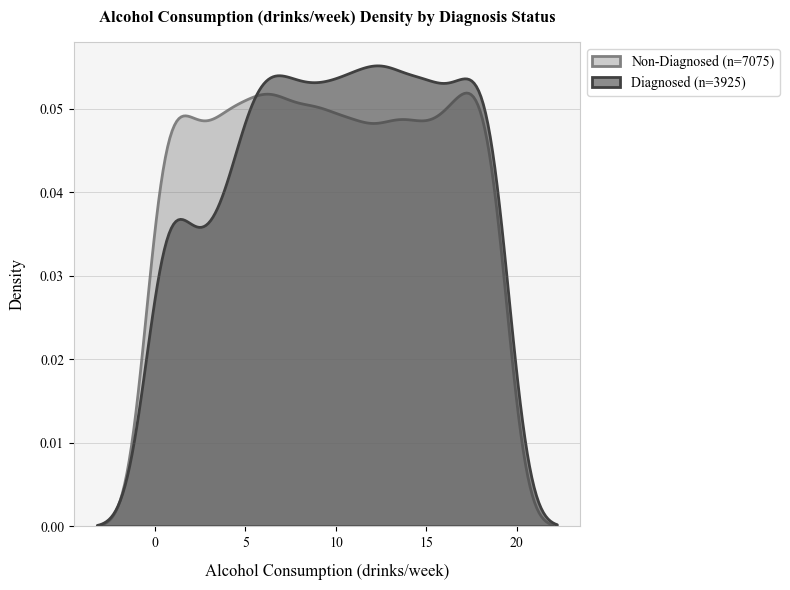

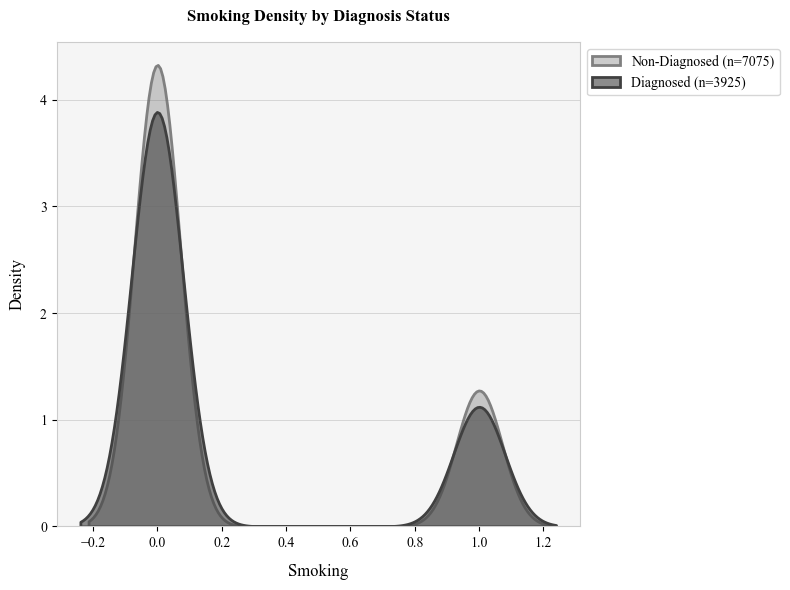

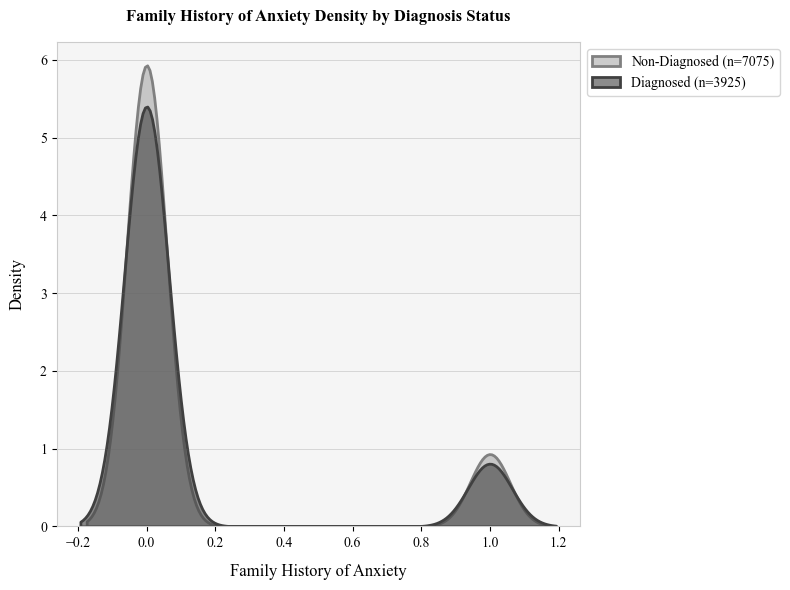

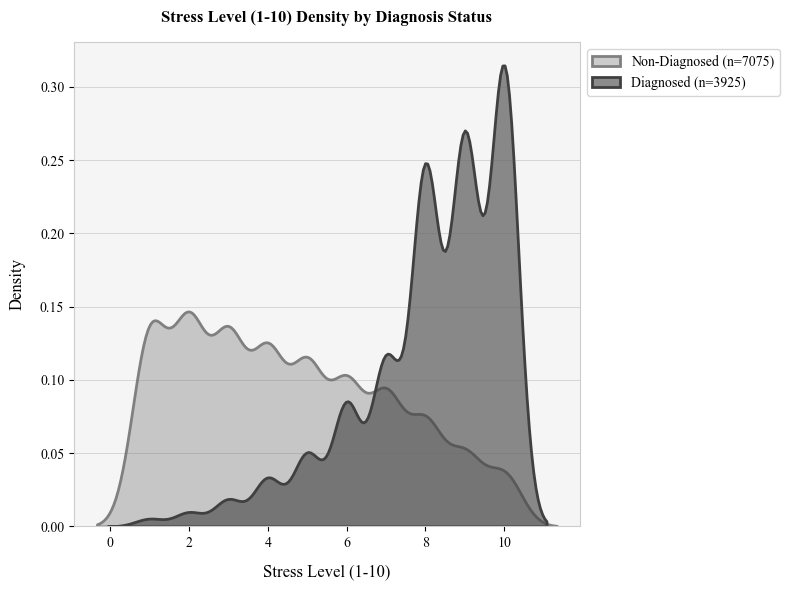

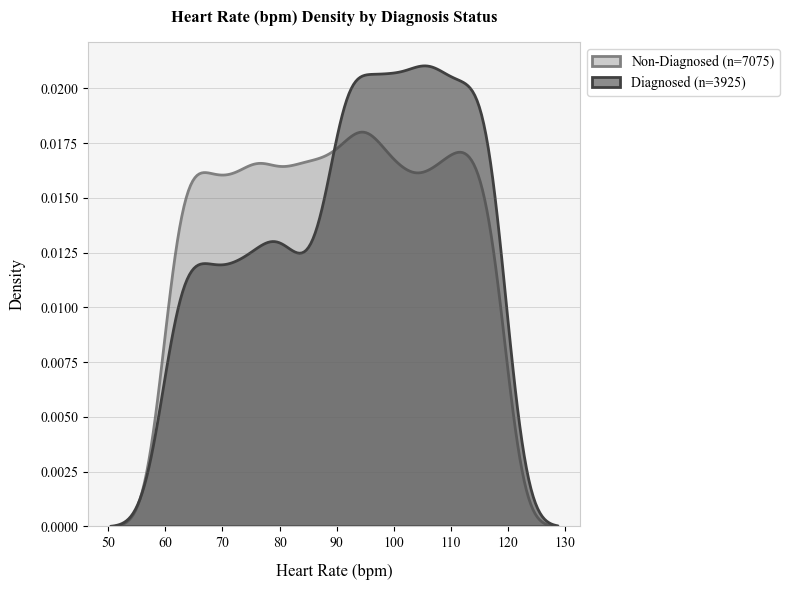

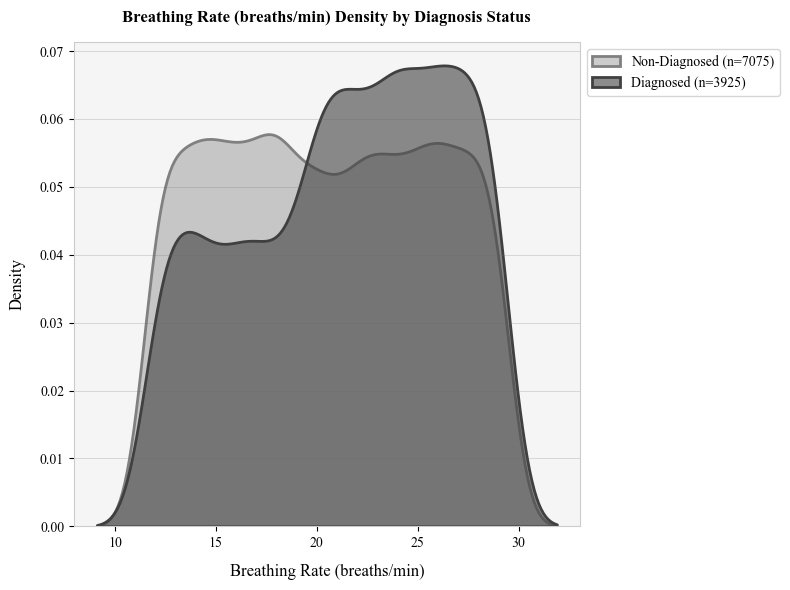

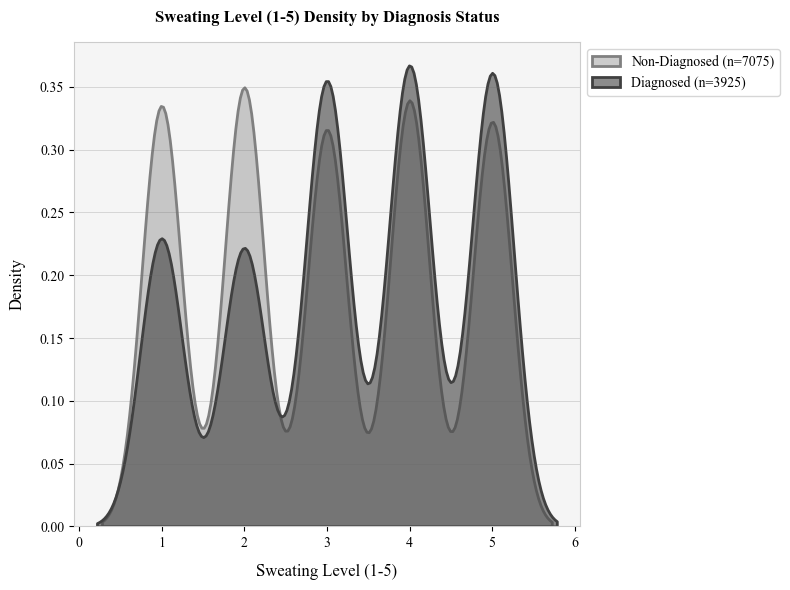

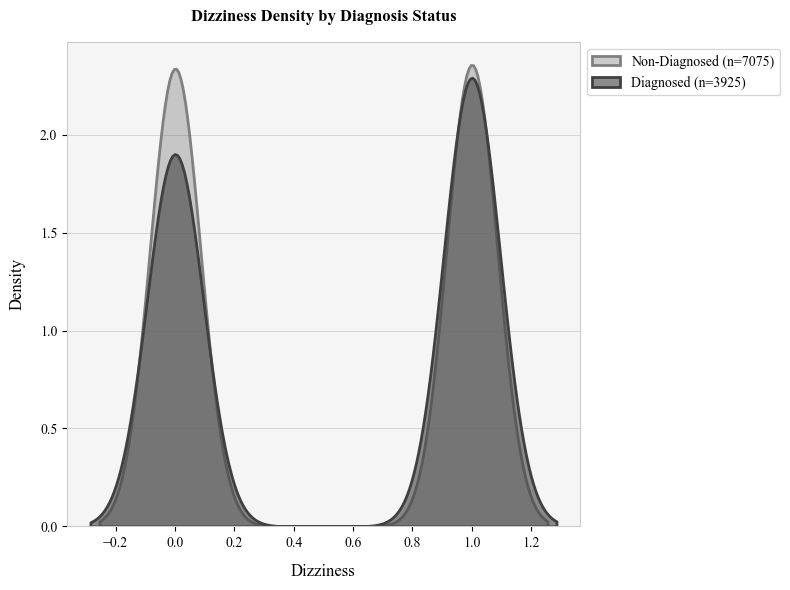

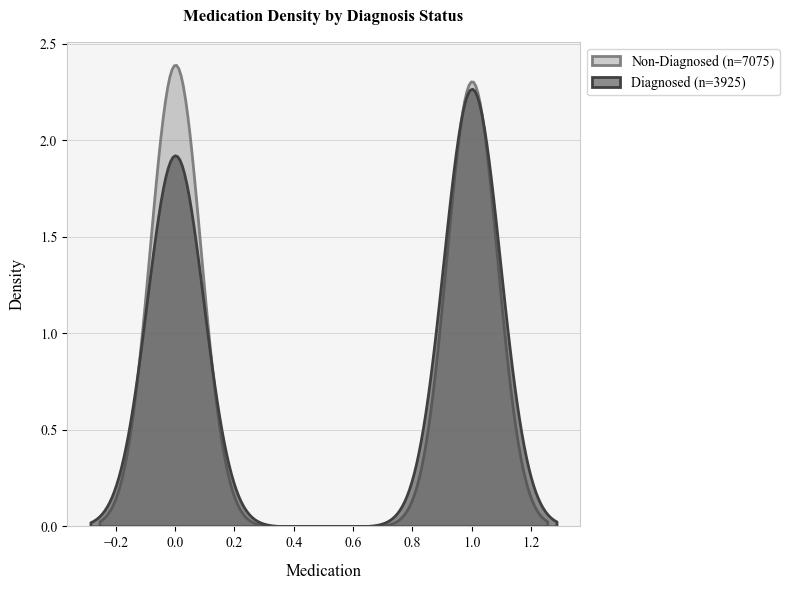

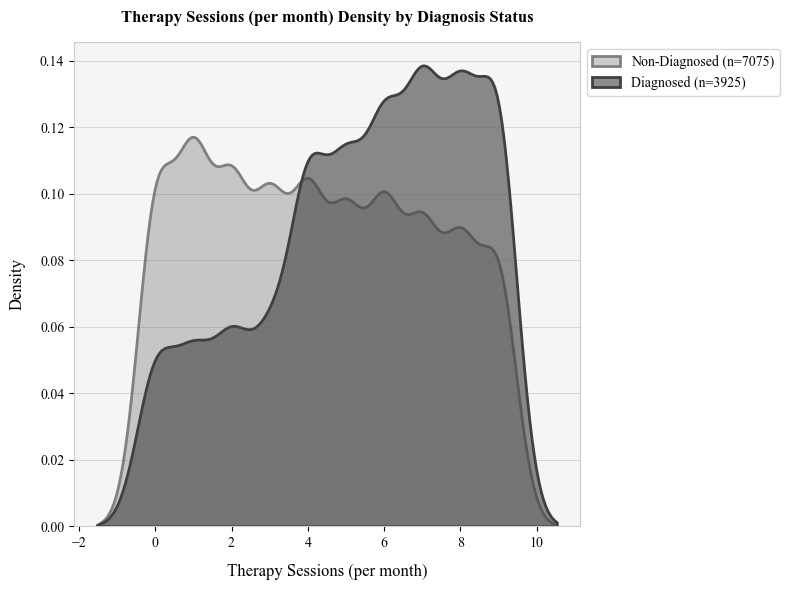

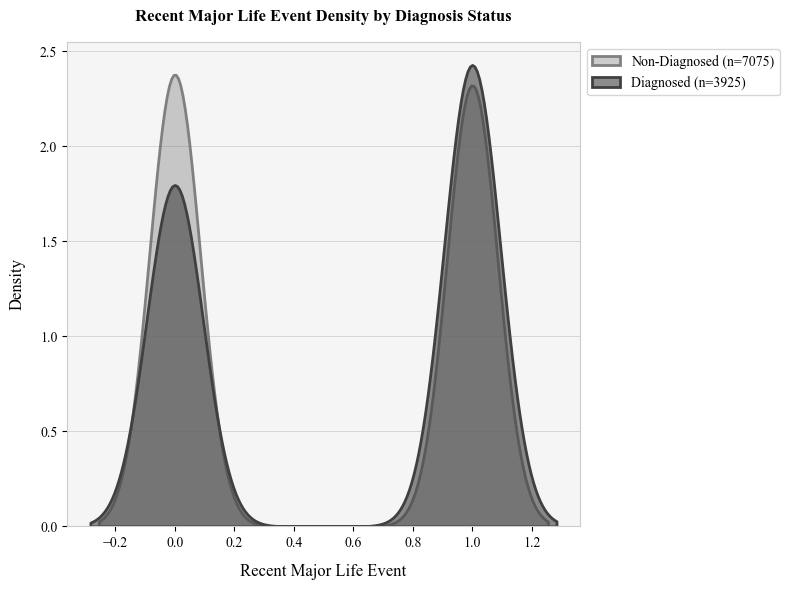

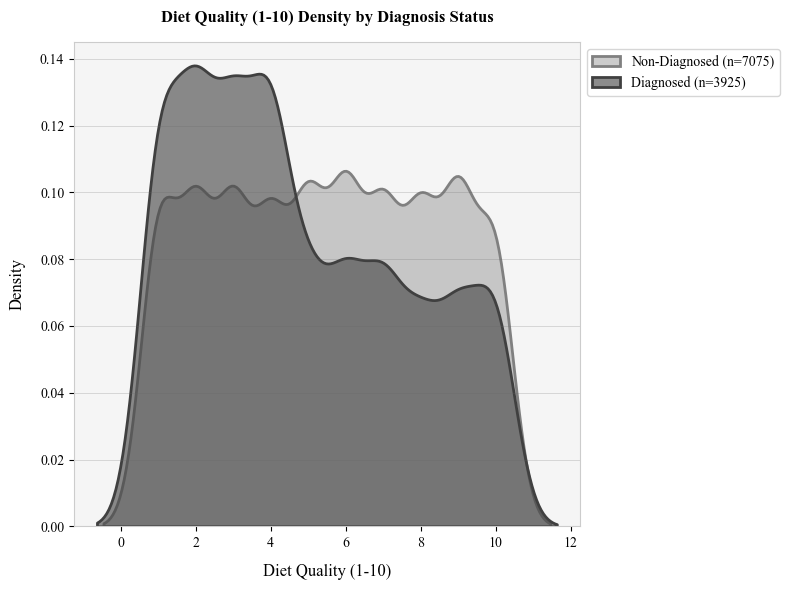

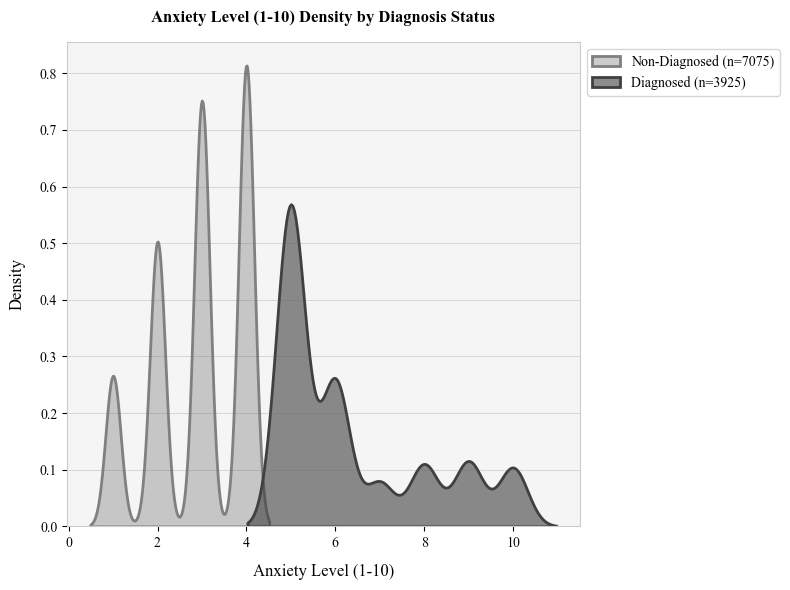

SKEWNESS AND KURTOSIS OF FEATURES
                                   Skewness  Kurtosis
Family History of Anxiety          2.154874  2.643963
Smoking                            1.308571 -0.287695
Anxiety Level (1-10)               0.918902  0.662642
Physical Activity (hrs/week)       0.490496 -0.272559
Stress Level (1-10)               -0.148151 -1.273465
Diet Quality (1-10)                0.139806 -1.217157
Heart Rate (bpm)                  -0.128128 -1.157126
Caffeine Intake (mg/day)          -0.115152 -1.186871
Therapy Sessions (per month)      -0.099686 -1.192781
Recent Major Life Event           -0.091380 -1.992012
Breathing Rate (breaths/min)      -0.090613 -1.199353
Sweating Level (1-5)              -0.088569 -1.269781
Dizziness                         -0.071692 -1.995223
Age                                0.061239 -1.156933
Alcohol Consumption (drinks/week) -0.040870 -1.176549
Medication                        -0.035283 -1.999119
Sleep Hours                       -0.011845 -0.2

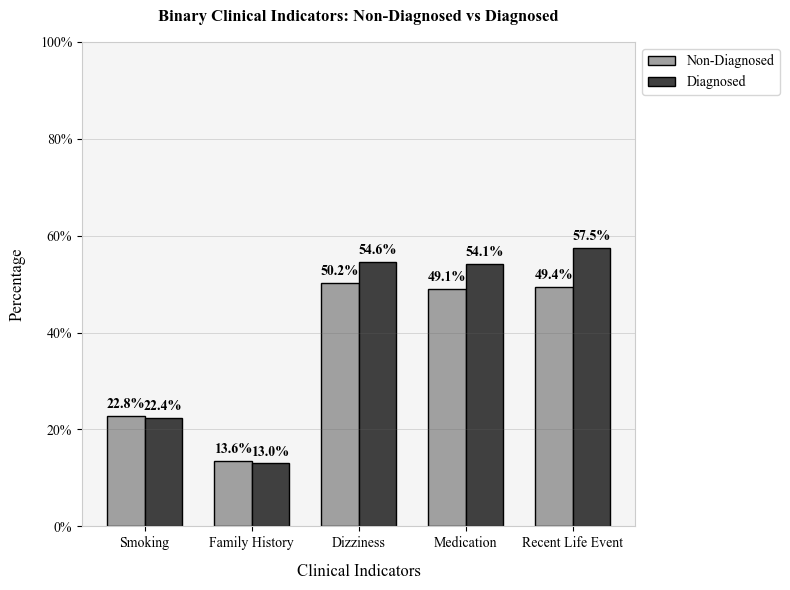


Binary Features - Percentage by Diagnosis Group:
------------------------------------------------------------
Smoking              Non-Diagnosed: 22.8%  |  Diagnosed: 22.4%  |  Difference: -0.4%
Family History       Non-Diagnosed: 13.6%  |  Diagnosed: 13.0%  |  Difference: -0.6%
Dizziness            Non-Diagnosed: 50.2%  |  Diagnosed: 54.6%  |  Difference: 4.4%
Medication           Non-Diagnosed: 49.1%  |  Diagnosed: 54.1%  |  Difference: 5.0%
Recent Life Event    Non-Diagnosed: 49.4%  |  Diagnosed: 57.5%  |  Difference: 8.1%

Dataset saved
Final dataset shape: 11000 rows, 20 columns


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set global font settings - consistent across all plots
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 12
plt.rcParams['figure.dpi'] = 100

# Define consistent styling function for all plots with grayscale
def style_plot(ax, title, xlabel, ylabel, legend=True, grid=True):
    """Apply consistent styling to plots with grayscale theme"""
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15, color='black')
    ax.set_xlabel(xlabel, fontsize=12, labelpad=10, color='black')
    ax.set_ylabel(ylabel, fontsize=12, labelpad=10, color='black')
    if grid:
        # Only show horizontal grid lines
        ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5, color='#666666')
        # Disable vertical grid lines
        ax.grid(False, axis='x')
    if legend:
        ax.legend(fontsize=10, frameon=True, loc='upper left', bbox_to_anchor=(1, 1))
    ax.tick_params(axis='both', which='major', labelsize=10, colors='black')
    ax.set_facecolor('#f5f5f5')
    ax.spines['top'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    ax.spines['left'].set_color('#cccccc')
    ax.spines['right'].set_color('#cccccc')
    return ax

# Load dataset
data = pd.read_csv("datasets/family_anxiety_14_dataset.csv") # training dataset
# data = pd.read_csv("datasets/enhanced_anxiety_dataset.csv") # testing dataset

# Display basic dataset information
print("DATASET DESCRIPTION")
print(f"Dataset shape: {data.shape[0]} rows, {data.shape[1]} columns")
print(f"Column names: {list(data.columns)}")
print(f"Data types:\n{data.dtypes}")
print(f"Missing values:\n{data.isnull().sum()}")

# Convert Yes/No columns to binary using map() instead of replace to avoid warning
yes_no_cols = ['Smoking', 'Family History of Anxiety', 'Dizziness', 
               'Medication', 'Recent Major Life Event']
for col in yes_no_cols:
    data[col] = data[col].map({'Yes': 1, 'No': 0})

# Creating target column: Diagnosed if Anxiety Level > 4
data['Diagnosed'] = (data['Anxiety Level (1-10)'] > 4).astype(int)

print("NEW TARGET COLUMN DIAGNOSED")
print(data[['Anxiety Level (1-10)', 'Diagnosed']].head())
print(f"Diagnosed distribution: 0 = {sum(data['Diagnosed']==0)}, 1 = {sum(data['Diagnosed']==1)}")

# Features vs target
features = data.drop(columns=['Diagnosed'])
target = data['Diagnosed']

# Display min and max for numeric features after conversion
numeric_features = features.select_dtypes(include=[np.number])

print("NUMERIC FEATURES MIN AND MAX VALUES")
for col in numeric_features.columns:
    print(f"{col}: Min = {numeric_features[col].min()}, Max = {numeric_features[col].max()}")
    
# statistical summary
print("STATISTICAL SUMMARY OF NUMERIC FEATURES")
print(numeric_features.describe())

# OUTLIER DETECTION FOR CONTINUOUS COLUMNS
print("OUTLIER DETECTION FOR CONTINUOUS COLUMNS")

# Identify continuous columns
continuous_cols = ['Age', 'Anxiety Level (1-10)', 'Sleep Hours', 'Physical Activity (hrs/week)']

print(f"Continuous columns: {continuous_cols}")

# IQR Method for outlier detection
def detect_outliers_iqr(data, columns):
    outlier_summary = {}
    
    for col in columns:
        if col in data.columns:
            Q1 = data[col].quantile(0.25)
            Q3 = data[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
            outlier_indices = outliers.index.tolist()
            
            outlier_summary[col] = {
                'Q1': Q1,
                'Q3': Q3,
                'IQR': IQR,
                'lower_bound': lower_bound,
                'upper_bound': upper_bound,
                'outlier_count': len(outliers),
                'outlier_percentage': (len(outliers) / len(data)) * 100,
                'outlier_indices': outlier_indices,
                'outlier_values': outliers[col].tolist()
            }
    
    return outlier_summary

# Z-Score Method for outlier detection
def detect_outliers_zscore(data, columns, threshold=3):
    outlier_summary = {}
    
    for col in columns:
        if col in data.columns:
            mean = data[col].mean()
            std = data[col].std()
            z_scores = np.abs((data[col] - mean) / std)
            
            outliers = data[z_scores > threshold]
            outlier_indices = outliers.index.tolist()
            
            outlier_summary[col] = {
                'mean': mean,
                'std': std,
                'threshold': threshold,
                'outlier_count': len(outliers),
                'outlier_percentage': (len(outliers) / len(data)) * 100,
                'outlier_indices': outlier_indices,
                'outlier_values': outliers[col].tolist(),
                'max_zscore': z_scores.max()
            }
    
    return outlier_summary

# Detect outliers using both methods
iqr_outliers = detect_outliers_iqr(data, continuous_cols)
zscore_outliers = detect_outliers_zscore(data, continuous_cols)

# Display IQR method results
print("IQR METHOD OUTLIER RESULTS")
for col, stats in iqr_outliers.items():
    print(f"{col}: {stats['outlier_count']} outliers ({stats['outlier_percentage']:.2f}%)")
    print(f"  Bounds: [{stats['lower_bound']:.2f}, {stats['upper_bound']:.2f}]")
    if stats['outlier_count'] > 0:
        print(f"  Outlier values: {stats['outlier_values']}")

# Display Z-Score method results
print("ZSCORE METHOD OUTLIER RESULTS")
for col, stats in zscore_outliers.items():
    print(f"{col}: {stats['outlier_count']} outliers ({stats['outlier_percentage']:.2f}%)")
    print(f"  Max ZScore: {stats['max_zscore']:.2f}")
    if stats['outlier_count'] > 0:
        print(f"  Outlier values: {stats['outlier_values']}")

# Numeric features correlation heatmap showing only high correlations
print("HIGH CORRELATIONS ABS > 0.2")
corr_matrix = numeric_features.corr(method='spearman')

# Create a mask for correlations with absolute value > 0.2
mask = np.abs(corr_matrix) > 0.2

# Remove diagonal
np.fill_diagonal(mask.values, False)

# Get pairs with high correlation
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if mask.iloc[i, j]:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

# Display high correlation pairs
if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    high_corr_df = high_corr_df.sort_values('Correlation', ascending=False)
    print(high_corr_df.to_string(index=False))
else:
    print("No correlations with absolute value > 0.2 found")

# Create heatmap only for high correlations with grayscale styling - UNIFORM FIGURE SIZE (8,6)
if high_corr_pairs:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    high_corr_features = list(set([item['Feature 1'] for item in high_corr_pairs] + 
                                  [item['Feature 2'] for item in high_corr_pairs]))
    
    high_corr_matrix = corr_matrix.loc[high_corr_features, high_corr_features]
    
    # Use grayscale colormap for correlation heatmap
    sns.heatmap(high_corr_matrix, annot=True, fmt=".2f",
                cmap="Greys", center=0, linewidths=0.2, square=True,
                annot_kws={'size': 10, 'color': 'black'}, 
                cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8}, ax=ax)
    ax = style_plot(ax, "Feature Correlation Matrix (|r| > 0.2)", 
                   "Features", "Features", legend=False, grid=False)
    plt.tight_layout()
    plt.show()

# 1. Target distribution plot - UNIFORM FIGURE SIZE (8,6)
fig, ax = plt.subplots(figsize=(8, 6))
bars = sns.countplot(x=data['Diagnosed'], palette=['#a0a0a0', '#404040'], 
                     legend=False, ax=ax, edgecolor='black', linewidth=1)
ax = style_plot(ax, "Target Variable Distribution", 
               "Diagnosis Status (0 = Non-Diagnosed, 1 = Diagnosed)", 
               "Count", legend=False)

total = len(data)
for bar in bars.patches:
    count = int(bar.get_height())
    percentage = count/total*100
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            f'{count}\n({percentage:.1f}%)', ha='center', va='bottom', 
            fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

# 2. Feature distribution - UNIFORM FIGURE SIZE (8,6)
numeric_cols = numeric_features.columns.tolist()

for col in numeric_cols:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    diagnosed_data = data[data['Diagnosed'] == 1][col]
    nondiagnosed_data = data[data['Diagnosed'] == 0][col]
    
    # Use grayscale colors
    ax.hist(nondiagnosed_data, bins=15, alpha=0.6, color='#a0a0a0', 
            label=f'Non-Diagnosed (n={len(nondiagnosed_data)})', 
            edgecolor='black', linewidth=0.5)
    ax.hist(diagnosed_data, bins=15, alpha=0.8, color='#404040', 
            label=f'Diagnosed (n={len(diagnosed_data)})', 
            edgecolor='black', linewidth=0.5)
    
    ax.axvline(nondiagnosed_data.mean(), color='#606060', linestyle='--', 
               linewidth=2, label=f'Mean Non-Diagnosed: {nondiagnosed_data.mean():.2f}')
    ax.axvline(diagnosed_data.mean(), color='black', linestyle='--', 
               linewidth=2, label=f'Mean Diagnosed: {diagnosed_data.mean():.2f}')
    
    ax = style_plot(ax, f'{col} Distribution by Diagnosis Status', col, 'Frequency')
    plt.tight_layout()
    plt.show()

# 3. Density plots - UNIFORM FIGURE SIZE (8,6)
for col in numeric_cols:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Use grayscale colors
    subset0 = data[data['Diagnosed'] == 0]
    subset1 = data[data['Diagnosed'] == 1]
    
    sns.kdeplot(data=subset0, x=col, color='#808080', 
                label=f'Non-Diagnosed (n={len(subset0)})', 
                fill=True, alpha=0.4, linewidth=2, ax=ax)
    sns.kdeplot(data=subset1, x=col, color='#404040', 
                label=f'Diagnosed (n={len(subset1)})', 
                fill=True, alpha=0.6, linewidth=2, ax=ax)
    
    ax = style_plot(ax, f'{col} Density by Diagnosis Status', col, 'Density')
    plt.tight_layout()
    plt.show()

# Skewness and kurtosis for numeric features
skew_kurt = pd.DataFrame({
    'Skewness': numeric_features.skew(),
    'Kurtosis': numeric_features.kurtosis()
}).sort_values(by='Skewness', key=abs, ascending=False)

print("SKEWNESS AND KURTOSIS OF FEATURES")
print(skew_kurt)

# Categorical features summary
categorical_features = features.select_dtypes(include=['object', 'category']).columns

print("CATEGORICAL FEATURES SUMMARY")
for col in categorical_features:
    print(f"Categorical Feature: {col}")
    print(f"Number of unique values: {data[col].nunique()}")
    print("Value counts top 10:")
    print(data[col].value_counts().head(10))

# 4. Paired bar chart for binary features - UNIFORM FIGURE SIZE (8,6)
print("\n" + "="*60)
print("BINARY FEATURES PERCENTAGES BY DIAGNOSIS GROUP")

binary_cols = ['Smoking', 'Family History of Anxiety', 'Dizziness', 
               'Medication', 'Recent Major Life Event']
feature_display_names = ['Smoking', 'Family History', 'Dizziness', 
                         'Medication', 'Recent Life Event']

non_diagnosed_pcts = []
diagnosed_pcts = []

for col in binary_cols:
    diag_1_pct = data[data['Diagnosed'] == 1][col].mean() * 100
    diag_0_pct = data[data['Diagnosed'] == 0][col].mean() * 100
    non_diagnosed_pcts.append(diag_0_pct)
    diagnosed_pcts.append(diag_1_pct)

# UNIFORM FIGURE SIZE (8,6) to match distribution graphs
fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(feature_display_names))
width = 0.35

# Use grayscale colors with consistent styling
bars1 = ax.bar(x - width/2, non_diagnosed_pcts, width, 
               label='Non-Diagnosed', color='#a0a0a0', 
               edgecolor='black', linewidth=1)
bars2 = ax.bar(x + width/2, diagnosed_pcts, width, 
               label='Diagnosed', color='#404040', 
               edgecolor='black', linewidth=1)

# Set xticks with consistent font size
ax.set_xticks(x)
ax.set_xticklabels(feature_display_names, fontsize=10)
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 20))
ax.set_yticklabels([f'{i}%' for i in np.arange(0, 101, 20)], fontsize=10)

# Apply consistent styling using the same style_plot function
ax = style_plot(ax, "Binary Clinical Indicators: Non-Diagnosed vs Diagnosed", 
                "Clinical Indicators", "Percentage")

# Add value labels with consistent font size
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

print("\nBinary Features - Percentage by Diagnosis Group:")
print("-" * 60)
for i, feature in enumerate(feature_display_names):
    print(f"{feature:20} Non-Diagnosed: {non_diagnosed_pcts[i]:.1f}%  |  Diagnosed: {diagnosed_pcts[i]:.1f}%  |  Difference: {diagnosed_pcts[i] - non_diagnosed_pcts[i]:.1f}%")

# Save cleaned dataset
data.to_csv("training_dataset.csv", index=False)
# data.to_csv("testing_dataset.csv", index=False)
print("\n" + "="*60)
print("Dataset saved")
print(f"Final dataset shape: {data.shape[0]} rows, {data.shape[1]} columns")